In [50]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df = pd.read_csv('/Users/armaganarslan/Desktop/pricing_data.csv')
df

,Date,City,Country,Customer Type,Gender,Product Category,Product,SKU,Unit Cost,Sales Price,Act.Price,Quantity,COGS,Discount,Disc.recalculated,Payment Method,Revenue,Profit
0,29-06-2024,Seattle,USA,Normal,Male,Groceries,Coffee (200g),1033,250,325,325.0,6,1500,100.00,0.0,Credit Card,1950.0,450.0
1,29-06-2024,Sheffield,UK,Member,Male,Groceries,Fruits,1024,80,104,104.0,9,720,93.60,0.0,Cash,936.0,216.0
2,29-06-2024,Kanpur,India,Normal,Female,Personal Care,Shampoo,1051,180,234,234.0,1,180,16.38,0.0,Credit Card,234.0,54.0
3,29-06-2024,Raichur,India,Normal,Male,Groceries,Energy Drink,1034,100,130,120.0,7,700,42.00,70.0,Cash,840.0,140.0
4,29-06-2024,Milwaukee,USA,Normal,Male,Groceries,Bread,1022,40,52,52.0,3,120,7.80,0.0,Cash,156.0,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9823,29-06-2025,Salvador,Brazil,Normal,Male,Clothing,Socks,1016,100,130,130.0,5,500,32.50,0.0,Cash,650.0,150.0
9824,29-06-2025,Ras Al Khaimah,UAE,Normal,Male,Electronics,Bluetooth Speaker,1005,2200,2860,2860.0,4,8800,286.00,0.0,Cash,11440.0,2640.0
9825,29-06-2025,San Jose,USA,Normal,Male,Groceries,Fruits,1024,80,104,96.0,4,320,38.40,32.0,E-Wallet,384.0,64.0
9826,29-06-2025,Montreal,Canada,Member,Male,Groceries,Bread,1022,40,52,50.0,2,80,10.00,4.0,Cash,100.0,20.0


In [28]:
# Summary statistics
print(df.describe())

               SKU     Unit Cost   Sales Price     Act.Price     Quantity  \
count  9828.000000   9828.000000   9828.000000   9828.000000  9828.000000   
mean   1023.783476   3194.254986   4152.588116   4057.774100     5.206960   
std      15.616399   9453.931238  12290.091764  12015.378325     2.202967   
min    1000.000000      3.000000      4.000000      3.450000     1.000000   
25%    1010.000000     55.000000     72.000000     71.500000     4.000000   
50%    1024.000000    140.000000    182.000000    182.000000     5.000000   
75%    1032.000000   1200.000000   1560.000000   1500.000000     7.000000   
max    1058.000000  55000.000000  71500.000000  71500.000000    10.000000   

                COGS      Discount  Disc.recalculated        Revenue  \
count    9828.000000   9828.000000        9828.000000    9828.000000   
mean    16520.039276    594.900703         495.297650   20981.051252   
std     53953.533467   1805.770585        3148.775682   68499.571526   
min         3.0000

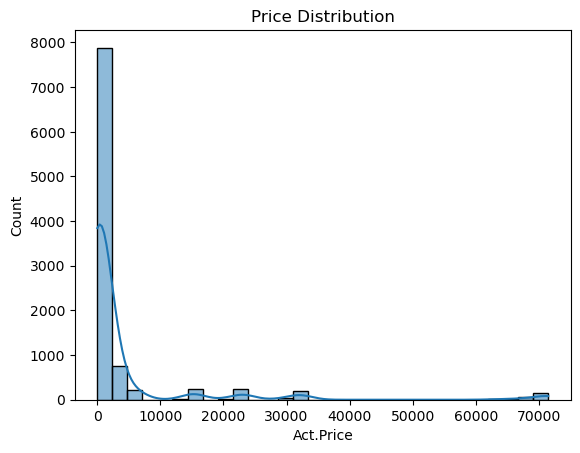

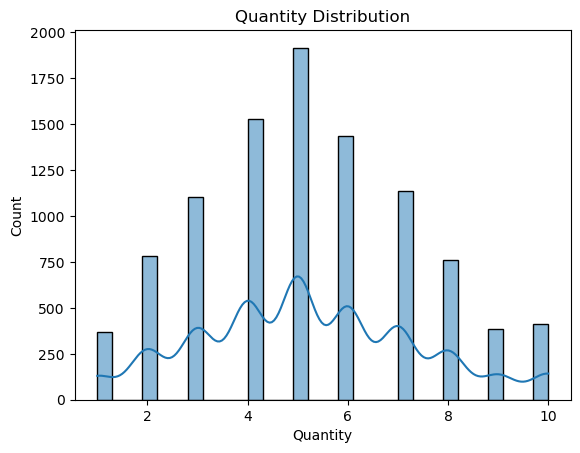

In [40]:
# Distribution plots
sns.histplot(df['Act.Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Quantity Distribution')
plt.show()

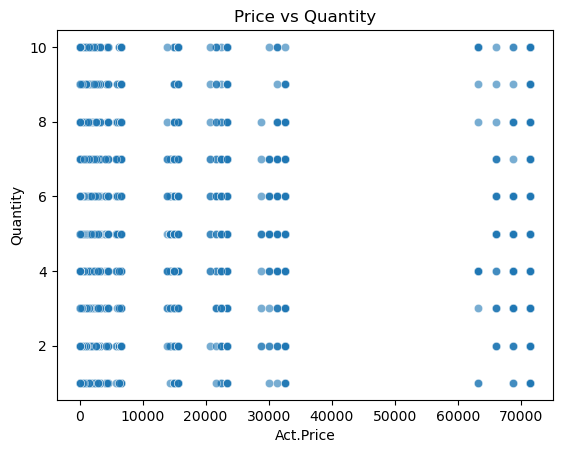

In [44]:
# Scatterplot to check inverse relation
sns.scatterplot(x='Act.Price', y='Quantity', data=df, alpha=0.6)
plt.title('Price vs Quantity')
plt.show()

In [46]:
# Correlation
corr = df['Act.Price'].corr(df['Quantity'])
print(f"Correlation between price and quantity: {corr:.2f}")

Correlation between price and quantity: -0.01


In [52]:
# Calculate log values for elasticity
df['log_price'] = np.log(df['Act.Price'])
df['log_qty'] = np.log(df['Quantity'])

# Regression: log(Q) vs log(P)
X = sm.add_constant(df['log_price'])
y = df['log_qty']
model = sm.OLS(y, X).fit()
print(model.summary())

elasticity = model.params['log_price']
print(f"Price Elasticity: {elasticity}")

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.231
Date:                Sat, 26 Jul 2025   Prob (F-statistic):              0.267
Time:                        17:43:13   Log-Likelihood:                -7404.3
No. Observations:                9828   AIC:                         1.481e+04
Df Residuals:                    9826   BIC:                         1.483e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5538      0.015    103.971      0.0

In [64]:
# 4. Optimal Price Calculation
# Optimal Price formula: Price / (1 + (1/Elasticity))
# Elasticity is negative, so take absolute value
df['Optimal_Price'] = df['Act.Price'] / (1 + (1 / abs(elasticity)))